# AIRPATH-AI Milestone 3B — road network and segment ETA

This notebook reproduces the bounded OpenStreetMap route/ETA example.

Scope safeguards:

- routes remain inside the HealthyAir stations 2–6 support polygon;
- supported modes are walking and motorbike only;
- travel time uses explicit constant speeds, not traffic prediction;
- candidate routes are not ranked by PM2.5;
- no spatial estimator or exposure calculation is called;
- exact segment ETAs do not imply minute-level PM2.5 support.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.eta_engine import DEFAULT_MODE_SPEED_KMH
from src.road_network import load_network, road_type_counts
from src.route_candidates import generate_milestone_outputs

In [2]:
network_path = PROJECT_ROOT / "data/processed/road_network/healthyair_pilot_osm.json.gz"
network = load_network(network_path)

{
    "osm_snapshot_timestamp": network.metadata["osm_snapshot_timestamp"],
    "all_nodes": len(network.nodes),
    "all_directed_edges": len(network.edges),
    "walking": network.mode_counts("walking"),
    "motorbike": network.mode_counts("motorbike"),
    "speed_assumptions_kmh": DEFAULT_MODE_SPEED_KMH,
}

{'osm_snapshot_timestamp': '2026-08-20T07:56:51Z',
 'all_nodes': 63013,
 'all_directed_edges': 142930,
 'walking': {'nodes': 62922, 'directed_edges': 142738},
 'motorbike': {'nodes': 57836, 'directed_edges': 122455},
 'speed_assumptions_kmh': {'walking': 5.0, 'motorbike': 25.0}}

In [3]:
outputs = generate_milestone_outputs(
    network_path,
    processed_directory=PROJECT_ROOT / "data/processed/road_network",
    report_root=PROJECT_ROOT / "reports",
    k=5,
)
outputs["route_summary"]

,route_id,mode,edge_count,total_distance_m,total_travel_time_seconds,origin_snap_distance_m,destination_snap_distance_m
0,walking-1,walking,126,3696.145633,2661.224856,21.262299,86.689142
1,walking-2,walking,125,3696.461955,2661.452608,21.262299,86.689142
2,walking-3,walking,125,3697.445807,2662.160981,21.262299,86.689142
3,walking-4,walking,124,3697.762129,2662.388733,21.262299,86.689142
4,walking-5,walking,125,3699.212021,2663.432655,21.262299,86.689142
5,motorbike-1,motorbike,141,3705.554683,533.599874,21.262299,86.689142
6,motorbike-2,motorbike,133,3705.838888,533.640800,21.262299,86.689142
7,motorbike-3,motorbike,138,3708.749142,534.059877,21.262299,86.689142
8,motorbike-4,motorbike,130,3709.033347,534.100802,21.262299,86.689142
9,motorbike-5,motorbike,140,3709.278853,534.136155,21.262299,86.689142


In [4]:
motorbike_segments = outputs["segment_table"].loc[
    outputs["segment_table"]["route_id"].eq("motorbike-1")
]
display(motorbike_segments.head(8))
display(motorbike_segments.tail(2))

# This is the future route-to-spatial contract only. It is not passed to
# estimate_pm25 during Milestone 3B.
outputs["spatial_targets"][:3]

,route_id,segment_index,edge_id,start_node,end_node,road_type,direction,mode,segment_geometry,representative_latitude,representative_longitude,segment_duration_seconds,entry_elapsed_seconds,cumulative_elapsed_seconds,entry_timestamp,target_arrival_timestamp,estimated_arrival_timestamp
625,motorbike-1,1,242307853:0:f,2498079018,2498079025,residential,forward,motorbike,"[[10.7802867, 106.6595074], [10.7802103, 106.6...",10.780248,106.659470,1.699483,0.000000,1.699483,2026-08-20T08:00:00+07:00,2026-08-20T08:00:00.849741709+07:00,2026-08-20T08:00:01.699483418+07:00
626,motorbike-1,2,32577686:2:f,2498079025,5772557724,secondary,forward,motorbike,"[[10.7802103, 106.6594324], [10.7801023, 106.6...",10.780156,106.659494,2.599628,1.699483,4.299111,2026-08-20T08:00:01.699483418+07:00,2026-08-20T08:00:02.999297271+07:00,2026-08-20T08:00:04.299111124+07:00
627,motorbike-1,3,32577686:3:f,5772557724,5772557748,secondary,forward,motorbike,"[[10.7801023, 106.6595558], [10.7799074, 106.6...",10.780005,106.659667,4.691469,4.299111,8.990580,2026-08-20T08:00:04.299111124+07:00,2026-08-20T08:00:06.644845485+07:00,2026-08-20T08:00:08.990579846+07:00
628,motorbike-1,4,32577686:4:f,5772557748,2498079023,secondary,forward,motorbike,"[[10.7799074, 106.6597785], [10.779422, 106.66...",10.779665,106.660056,11.683723,8.990580,20.674303,2026-08-20T08:00:08.990579846+07:00,2026-08-20T08:00:14.832441495+07:00,2026-08-20T08:00:20.674303145+07:00
629,motorbike-1,5,609435506:2:f,2498079023,2498079024,service,forward,motorbike,"[[10.779422, 106.6603331], [10.7794909, 106.66...",10.779456,106.660366,1.518124,20.674303,22.192427,2026-08-20T08:00:20.674303145+07:00,2026-08-20T08:00:21.433364923+07:00,2026-08-20T08:00:22.192426702+07:00
630,motorbike-1,6,242307850:7:r,2498079024,2498079026,service,reverse,motorbike,"[[10.7794909, 106.6603994], [10.7795728, 106.6...",10.779532,106.660441,1.842711,22.192427,24.035137,2026-08-20T08:00:22.192426702+07:00,2026-08-20T08:00:23.113781978+07:00,2026-08-20T08:00:24.035137255+07:00
631,motorbike-1,7,242307850:6:r,2498079026,5772557711,service,reverse,motorbike,"[[10.7795728, 106.6604817], [10.7797695, 106.6...",10.779671,106.660579,4.388679,24.035137,28.423816,2026-08-20T08:00:24.035137255+07:00,2026-08-20T08:00:26.229476693+07:00,2026-08-20T08:00:28.423816131+07:00
632,motorbike-1,8,242307850:5:r,5772557711,11306427663,service,reverse,motorbike,"[[10.7797695, 106.660676], [10.7799194, 106.66...",10.779844,106.660760,3.559428,28.423816,31.983244,2026-08-20T08:00:28.423816131+07:00,2026-08-20T08:00:30.203530176+07:00,2026-08-20T08:00:31.983244221+07:00


,route_id,segment_index,edge_id,start_node,end_node,road_type,direction,mode,segment_geometry,representative_latitude,representative_longitude,segment_duration_seconds,entry_elapsed_seconds,cumulative_elapsed_seconds,entry_timestamp,target_arrival_timestamp,estimated_arrival_timestamp
764,motorbike-1,140,244791434:1:f,2520636903,2520636901,service,forward,motorbike,"[[10.7765181, 106.6866254], [10.7767514, 106.6...",10.776635,106.686729,4.960644,524.187280,529.147923,2026-08-20T08:08:44.187279634+07:00,2026-08-20T08:08:46.667601411+07:00,2026-08-20T08:08:49.147923189+07:00
765,motorbike-1,141,244791433:1:f,2520636901,2520636899,service,forward,motorbike,"[[10.7767514, 106.6868329], [10.7765637, 106.6...",10.776658,106.686937,4.451951,529.147923,533.599874,2026-08-20T08:08:49.147923189+07:00,2026-08-20T08:08:51.373898781+07:00,2026-08-20T08:08:53.599874373+07:00


[{'route_id': 'walking-1',
  'segment_index': 1,
  'edge_id': '242307849:3:r',
  'latitude': 10.780017099999998,
  'longitude': 106.65980959999999,
  'target_time': Timestamp('2026-08-20 08:00:32.105555178+0700', tz='UTC+07:00')},
 {'route_id': 'walking-1',
  'segment_index': 2,
  'edge_id': '242307849:2:r',
  'latitude': 10.779619199999999,
  'longitude': 106.6602556,
  'target_time': Timestamp('2026-08-20 08:01:19.489024452+0700', tz='UTC+07:00')},
 {'route_id': 'walking-1',
  'segment_index': 3,
  'edge_id': '242307850:7:r',
  'latitude': 10.779531850000001,
  'longitude': 106.66044055,
  'target_time': Timestamp('2026-08-20 08:01:39.373714932+0700', tz='UTC+07:00')}]

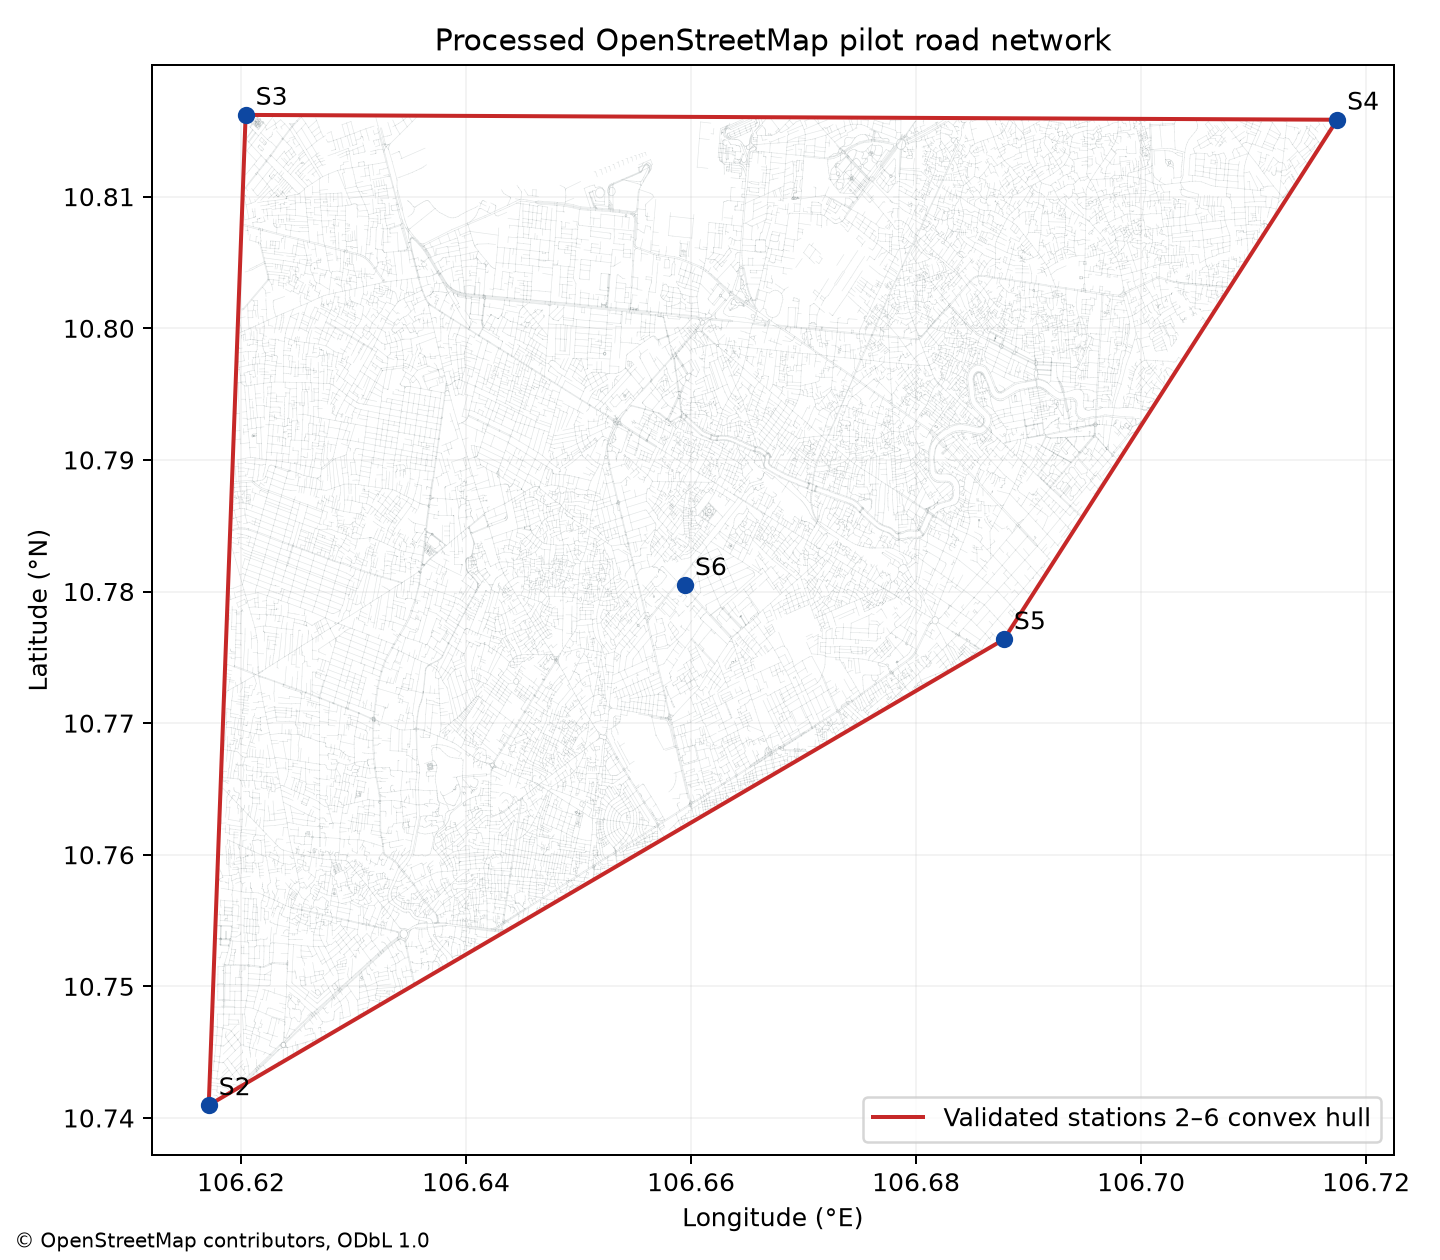

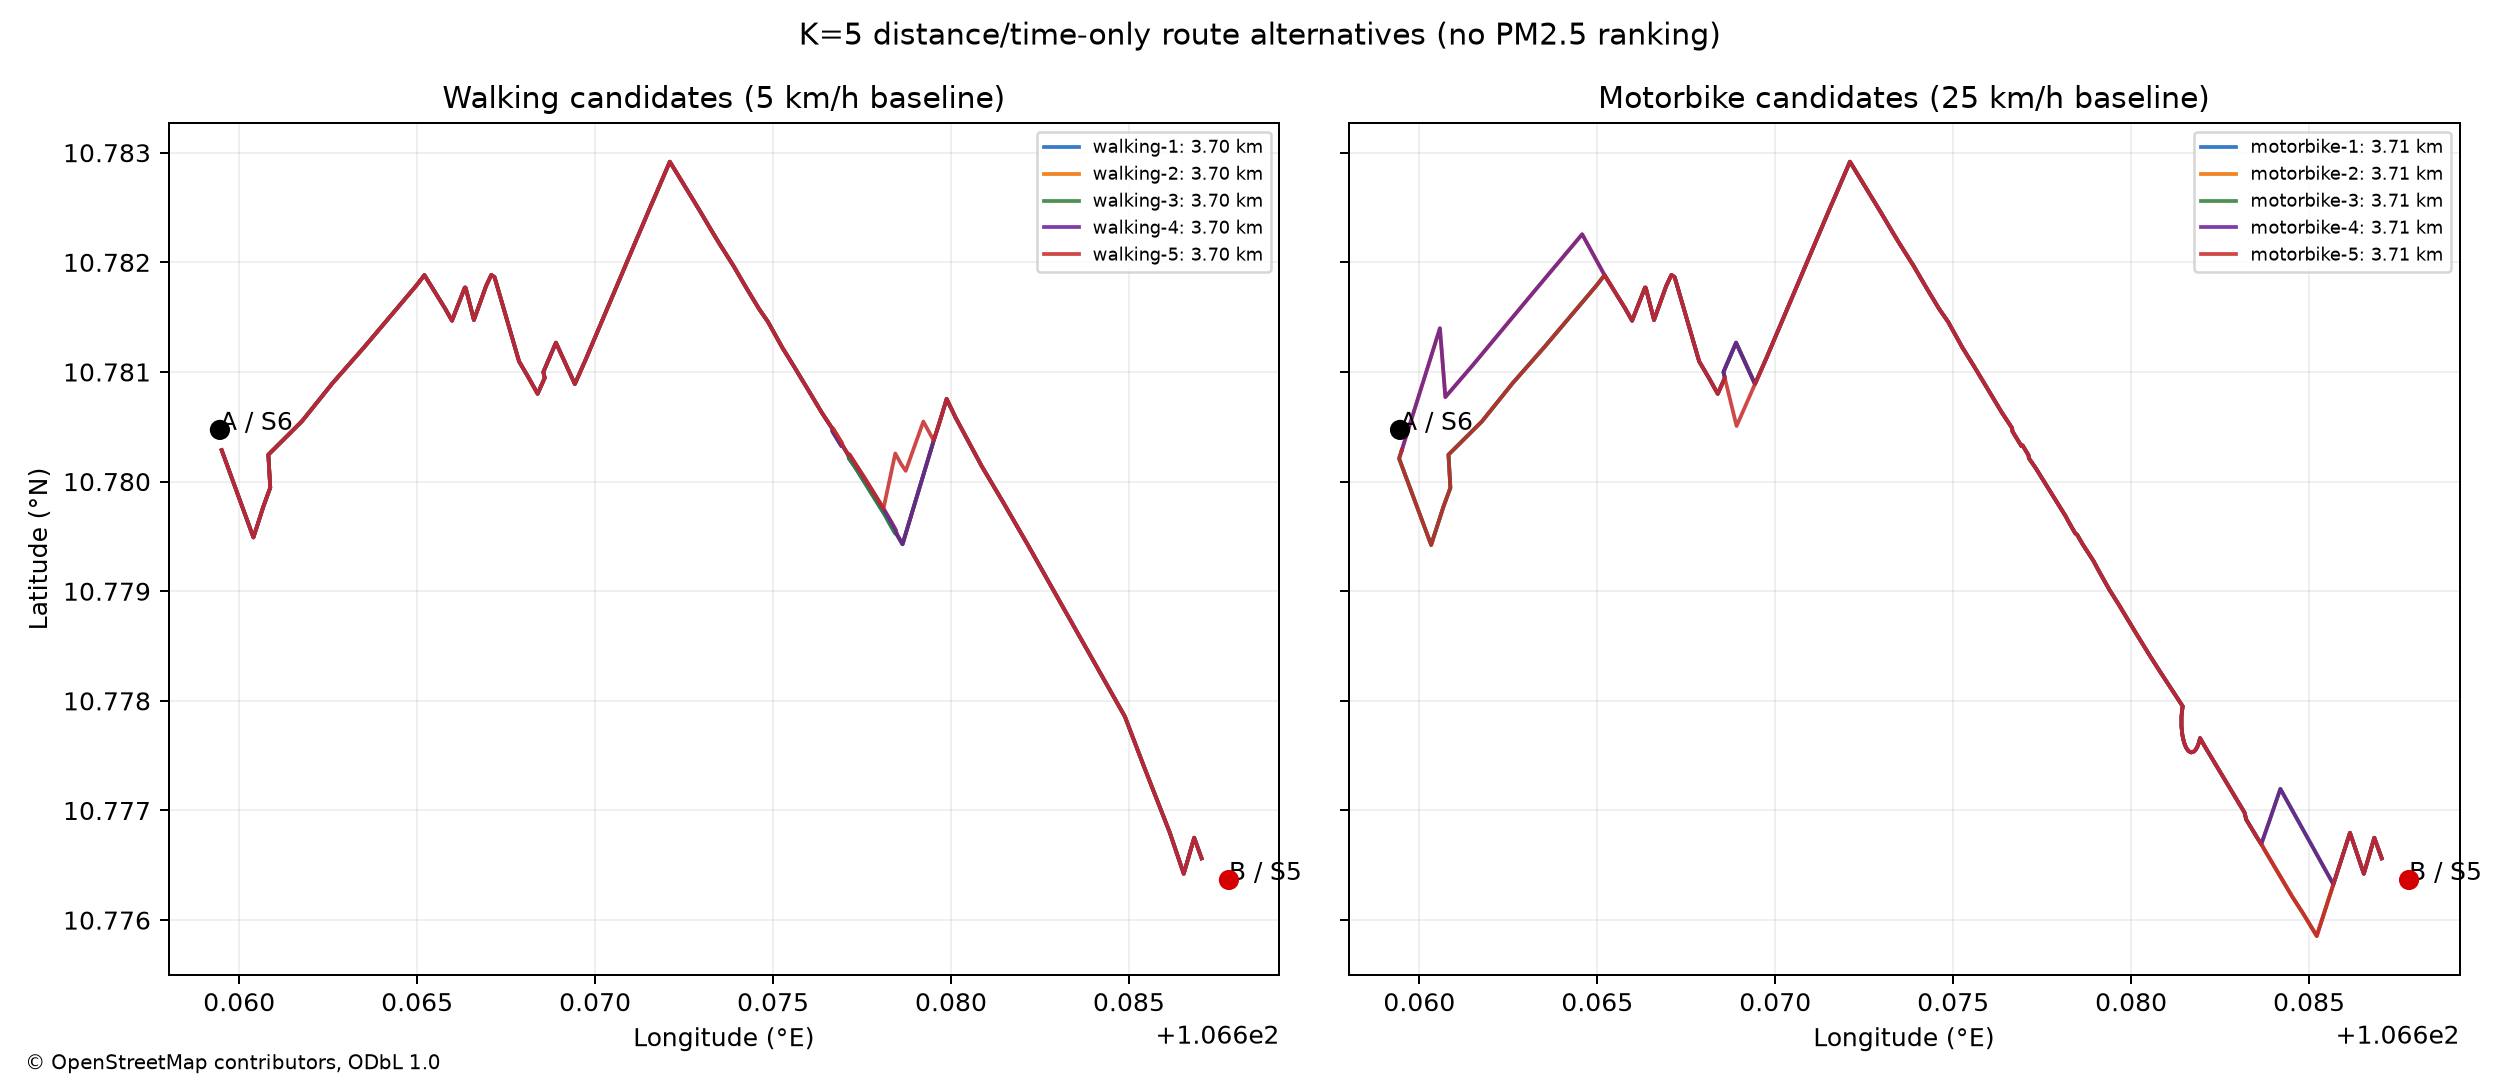

In [5]:
display(Image(filename=PROJECT_ROOT / "reports/figures/road_network_pilot.png"))
display(Image(filename=PROJECT_ROOT / "reports/figures/road_network_candidate_routes.png"))